## Final anndata object of the 10X Galapagos drug perturbation project

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import ma_codes as codes
from ma_codes import mysize, mymap, gray_red

Running Scanpy 1.6.1.dev110+gb4234d81, on 2021-03-02 09:00.


In [2]:
## path variables
adata_path = '/mnt/platte_1/Projects/210115_GLPG/210129_GLPG_souped_filtered.h5ad'

In [3]:
## plotting variables
sc.settings.figdir = '/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/processing_NIKLAS/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_path)

In [5]:
## have a look at the adata object: 517376 cells x 27868 genes
adata

AnnData object with n_obs × n_vars = 459907 × 26141
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'GLPG_annotation', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'GLPG_annotation_colors', 'cluster_03_colors', 'condition_colors', 'hvg', 'identifier_colors', 'louvain', 'louvain_1_colors', 'louvain_2_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

### Remove outlier sample

In [6]:
adata = adata[-adata.obs['identifier'].isin(['d10BLM_Nint57'])]

### Calculate HVGs

In [7]:
## delete all obs colums related to highly variable genes
del(adata.var['highly_variable'])
del(adata.var['highly_variable_nbatches'])
del(adata.var['highly_variable_intersection'])

In [8]:
## filter genes
sc.pp.filter_genes(adata, min_counts = 1)
sc.pp.filter_genes(adata, min_cells = 10)

filtered out 2 genes that are detected in less than 1 counts
Trying to set attribute `.var` of view, copying.
filtered out 945 genes that are detected in less than 10 cells


extracting highly variable genes
/home/agando/anaconda3/lib/python3.7/site-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)
    finished (0:00:48)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
/home/agando/anaconda3/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


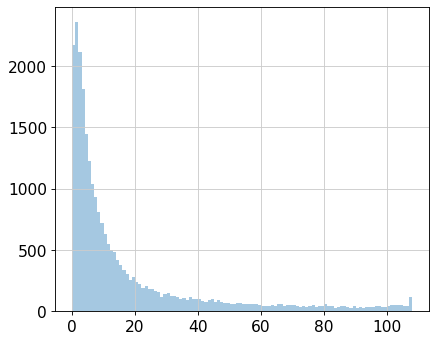

In [9]:
## compute HVGs per batch ('identifier') using seurat method
batch = 'identifier'
sc.pp.highly_variable_genes(adata, min_disp = None, max_disp = None, min_mean = None, max_mean = None, 
                                batch_key = batch, n_top_genes = 4000, n_bins = 20, flavor = 'seurat', 
                                subset = False)
vartab = pd.DataFrame(adata.var['highly_variable_nbatches'], index = adata.var_names)
sb.distplot(vartab, kde = False, bins = len(np.unique(adata.obs[batch])))

In [10]:
## only consider a gene as variabel if variable in at least 10 batches
thresh = 10
hvgs = vartab[vartab.highly_variable_nbatches.values >= thresh].index
print('%s Genes kept, variable in at least %s samples' %(len(hvgs), thresh))

10578 Genes kept, variable in at least 10 samples


In [11]:
## remove cell cycle genes (MOUSE) from list of HVGs
cc_genes = [x.strip().capitalize() for x in open('/home/agando/Documents/Meshal/PhD_Scripts/' +
                                                 'for_orientation/regev_lab_cell_cycle_genes.txt')]
hvgs = np.setdiff1d(hvgs, cc_genes)

In [12]:
## set HVGs
adata.var['highly_variable'] = [g in hvgs for g in adata.var_names]
## no. of resulting HVGs
sum(adata.var['highly_variable'])

10515

### PCA

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:02:12)


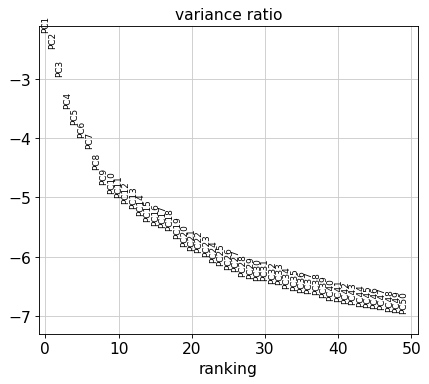

In [13]:
## PCA
sc.pp.pca(adata, use_highly_variable = True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### Graph-based clustering and Visualization

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:08:25)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 35 clusters and added
    'louvain_1', the cluster labels (adata.obs, categorical) (0:09:26)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 48 clusters and added
    'louvain_2', the cluster labels (adata.obs, categorical) (0:07:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:10:09)


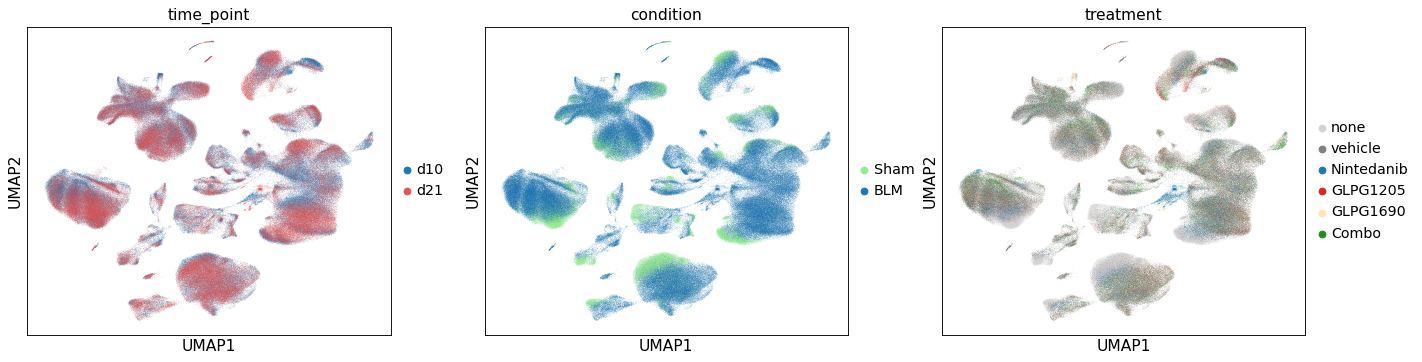

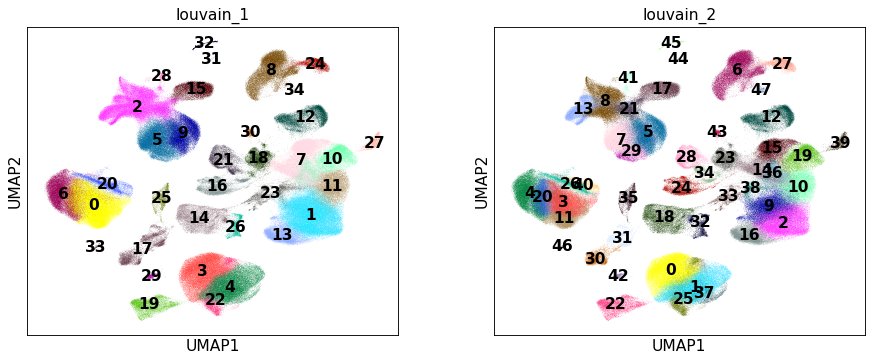

In [14]:
## graph based clustering
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 30)
sc.tl.louvain(adata, resolution = 1.0, key_added = 'louvain_1')
sc.tl.louvain(adata, resolution = 2.0, key_added = 'louvain_2')
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['time_point', 'condition','treatment'])
sc.pl.umap(adata, color = ['louvain_1', 'louvain_2'], legend_loc = 'on data')

### Subsetting data

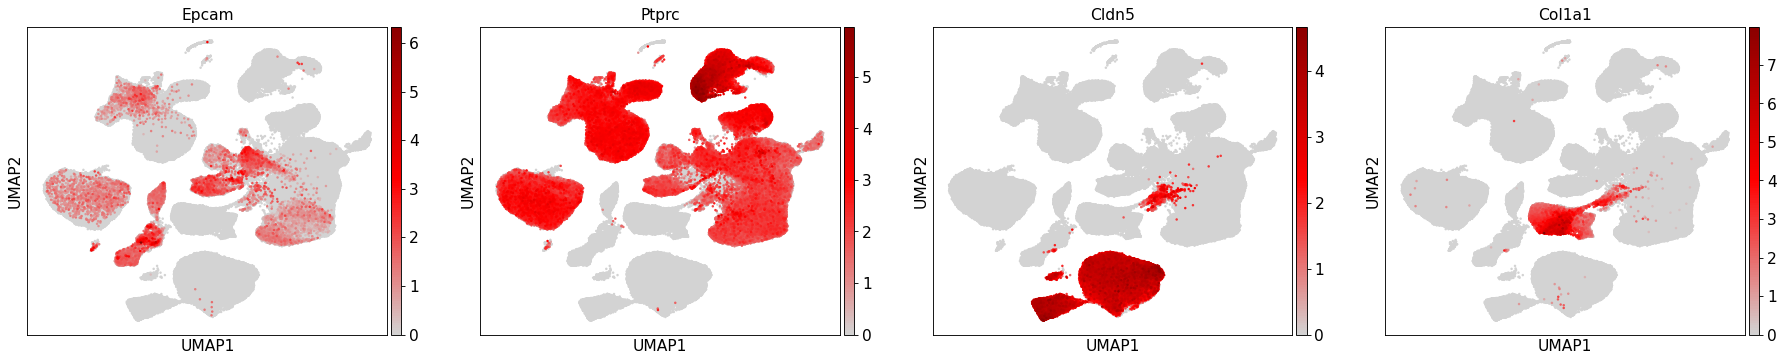

In [15]:
sc.pl.umap(adata, color = ['Epcam', 'Ptprc', 'Cldn5', 'Col1a1'], size = 20, cmap = gray_red)

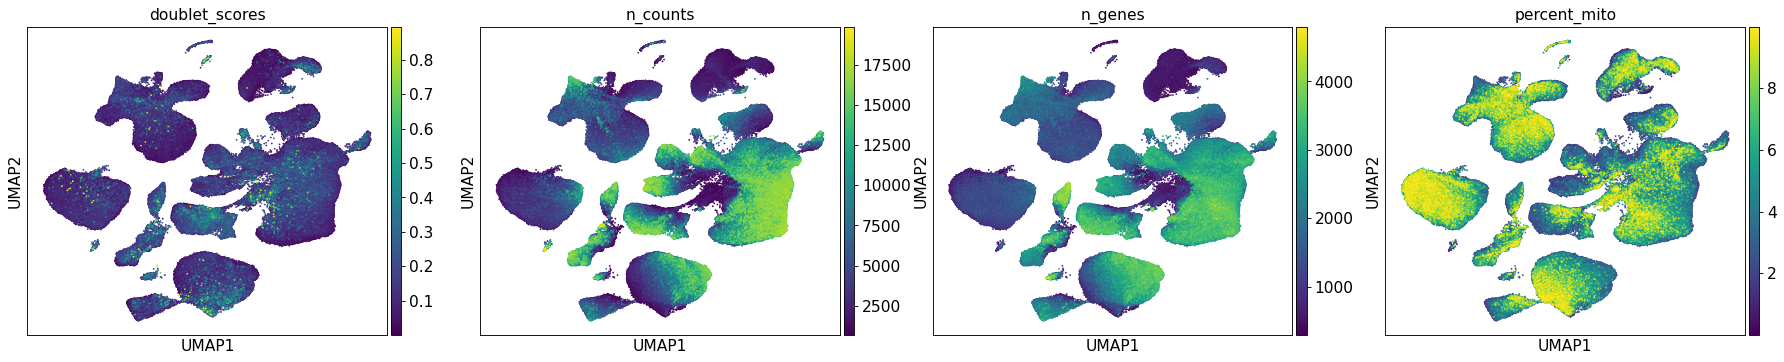

In [16]:
sc.pl.umap(adata, color = ['doublet_scores', 'n_counts', 'n_genes', 'percent_mito'], size = 10)

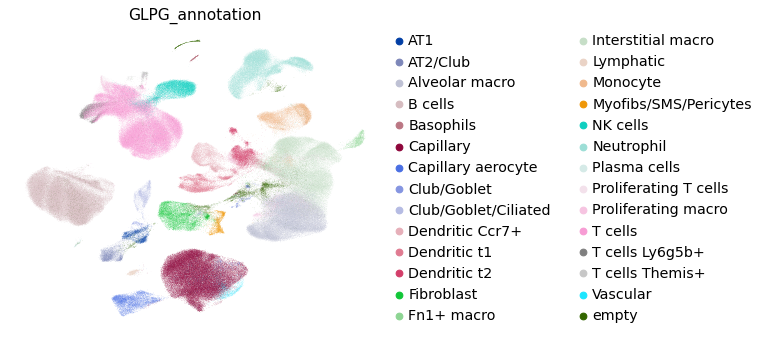

In [17]:
sc.pl.umap(adata, color = ['GLPG_annotation'], frameon=False)

In [18]:
## save data
adata.write('/mnt/platte_1/Projects/210115_GLPG/210211_GLPG_souped_filtered_NIKLAS.h5ad')

## Epcam+ subset

### Plot marker genes

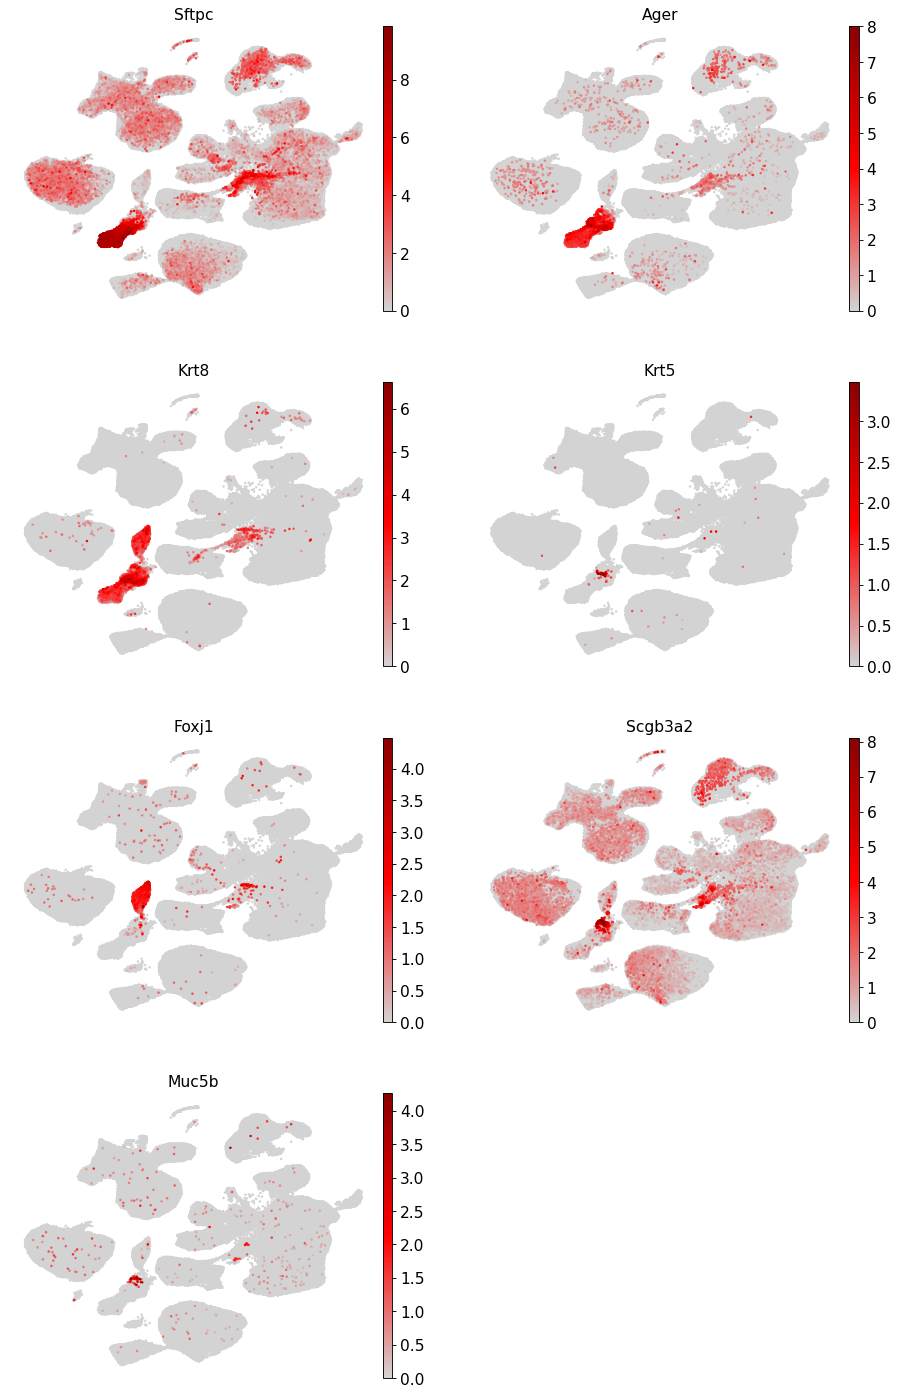

In [19]:
sc.pl.umap(adata, color = ['Sftpc','Ager','Krt8','Krt5','Foxj1','Scgb3a2','Muc5b'], ncols=2, size=20, 
           color_map = gray_red, frameon = False)

### Save Epcam+ subset

In [20]:
epcam_subset = adata[adata.obs['louvain_1'].isin(['17','25'])]

In [21]:
epcam_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_epcam+_subset_NIKLAS.h5ad')

## Cldn5+ subset

### Plot marker genes

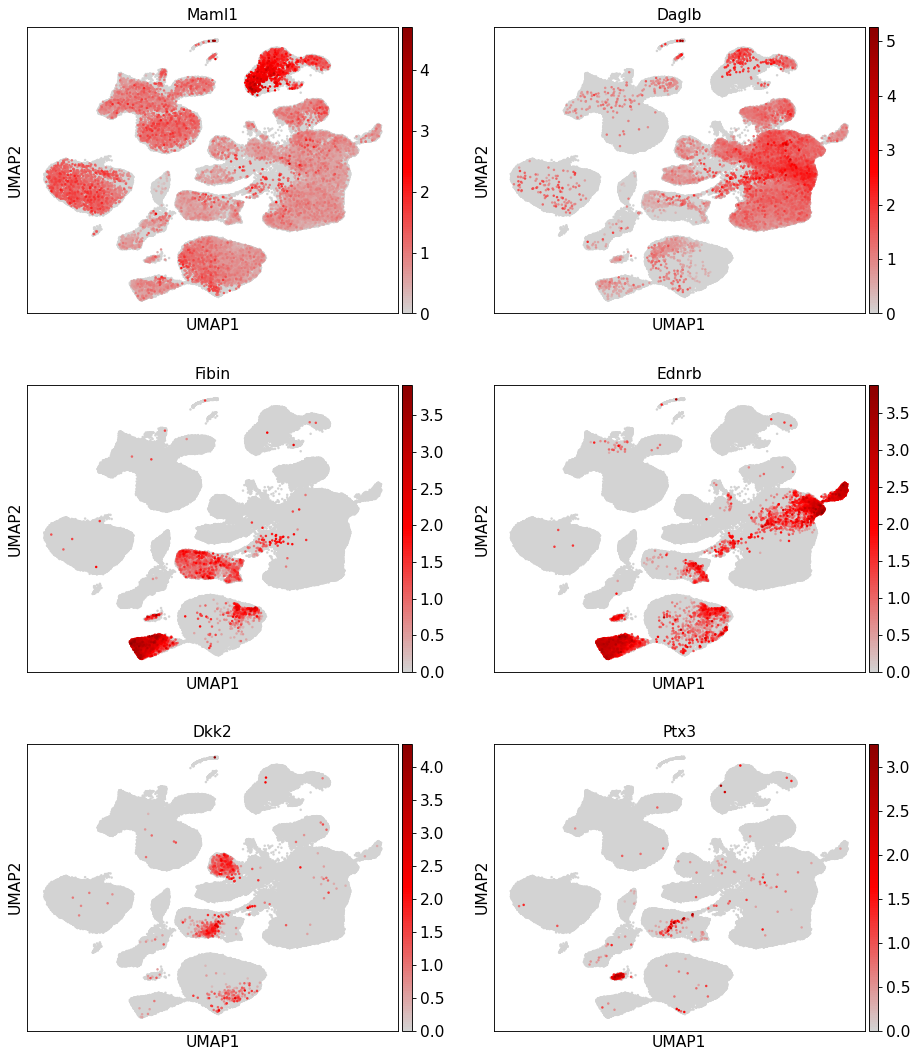

In [22]:
sc.pl.umap(adata, color = ['Maml1', 'Daglb', 'Fibin', 'Ednrb','Dkk2', 'Ptx3'], ncols=2, size=20, 
           color_map=gray_red)

### Save Cldn5+ subset

In [23]:
cldn5_subset = adata[adata.obs['louvain_1'].isin(['3','4','19','22','29'])]

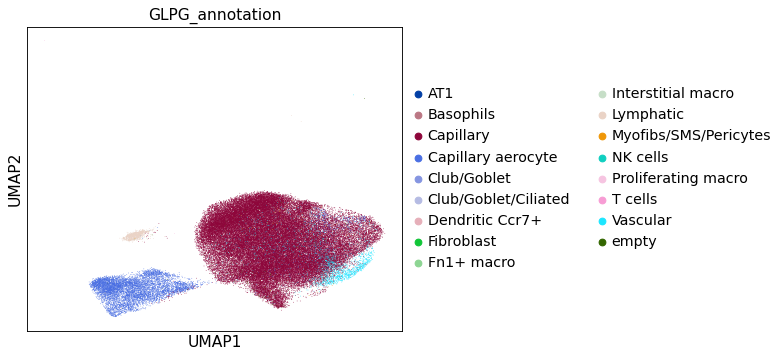

In [24]:
sc.pl.umap(cldn5_subset, color = ['GLPG_annotation'])

In [25]:
cldn5_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_cldn5+_subset_NIKLAS.h5ad')

## Col1a1+ subset

### Plot marker genes

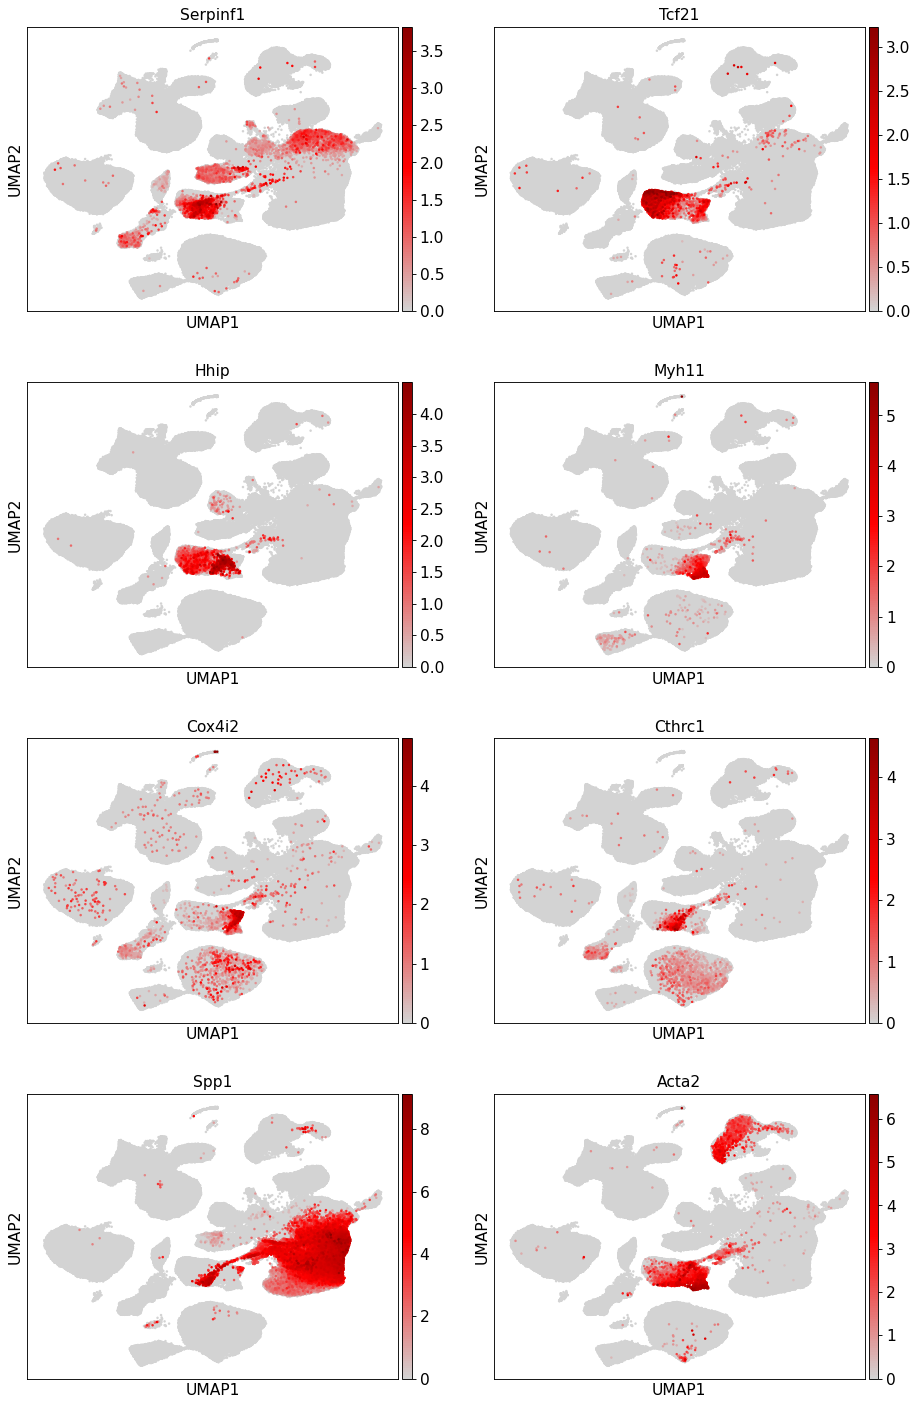

In [26]:
sc.pl.umap(adata, color = ['Serpinf1','Tcf21','Hhip','Myh11','Cox4i2','Cthrc1','Spp1','Acta2'], ncols=2, size=20, 
           color_map=gray_red)

### Save Col1a1+ subset

In [27]:
col1a1_subset = adata[adata.obs['louvain_1'].isin(['14','26'])]

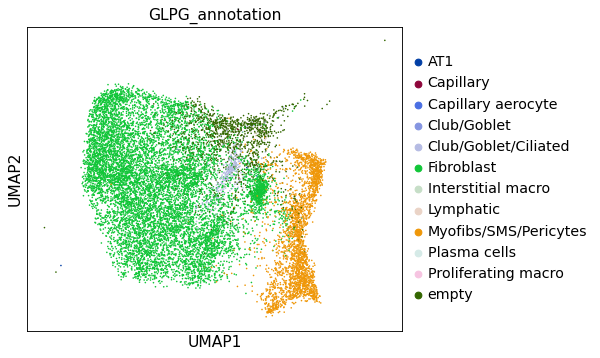

In [28]:
sc.pl.umap(col1a1_subset, color = ['GLPG_annotation'])

In [29]:
col1a1_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_col1a1+_subset_NIKLAS.h5ad')

## Mononuclear Phagocytes subset

### Plot marker genes

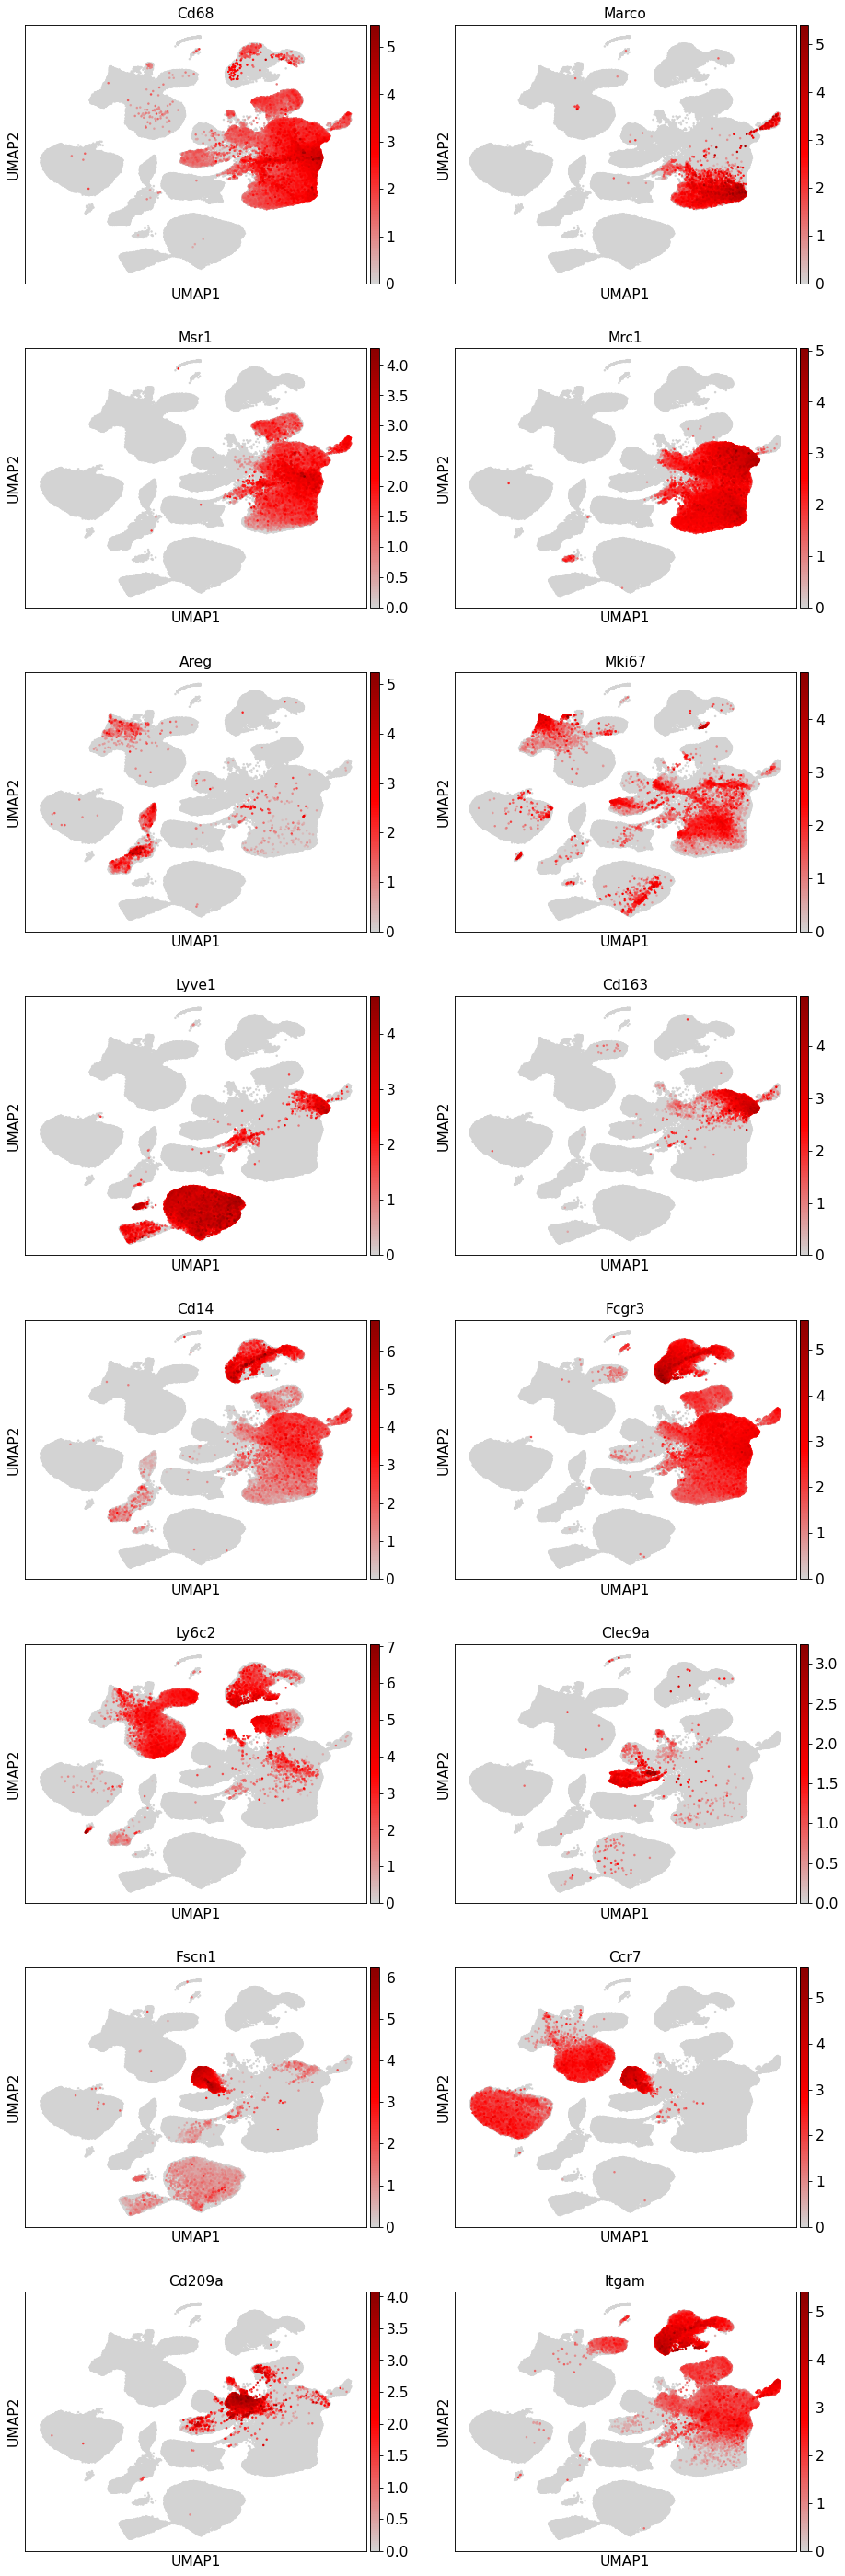

In [30]:
sc.pl.umap(adata, color = ['Cd68', 'Marco', 'Msr1', 'Mrc1', 'Areg', 'Mki67',
                           'Lyve1', 'Cd163', 'Cd14', 'Fcgr3', 'Ly6c2',
                           'Clec9a', 'Fscn1', 'Ccr7', 'Cd209a', 'Itgam'], ncols=2, size=20, color_map= gray_red)

### Save Mononuclear Phagocytes subset

In [31]:
mnp_subset = adata[adata.obs['louvain_1'].isin(['13', '1', '11', '10', '7', '27', # Macrophages
                                               '12', # Monocytes
                                                '16', '18', '21', '30' # DCs
                                               ])]

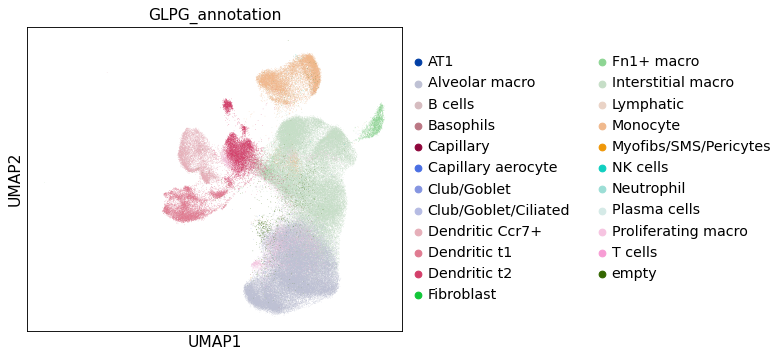

In [32]:
sc.pl.umap(mnp_subset, color=['GLPG_annotation'])

In [33]:
mnp_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_mnp_subset_NIKLAS.h5ad')

## Granulocyte subset

### Plot marker genes

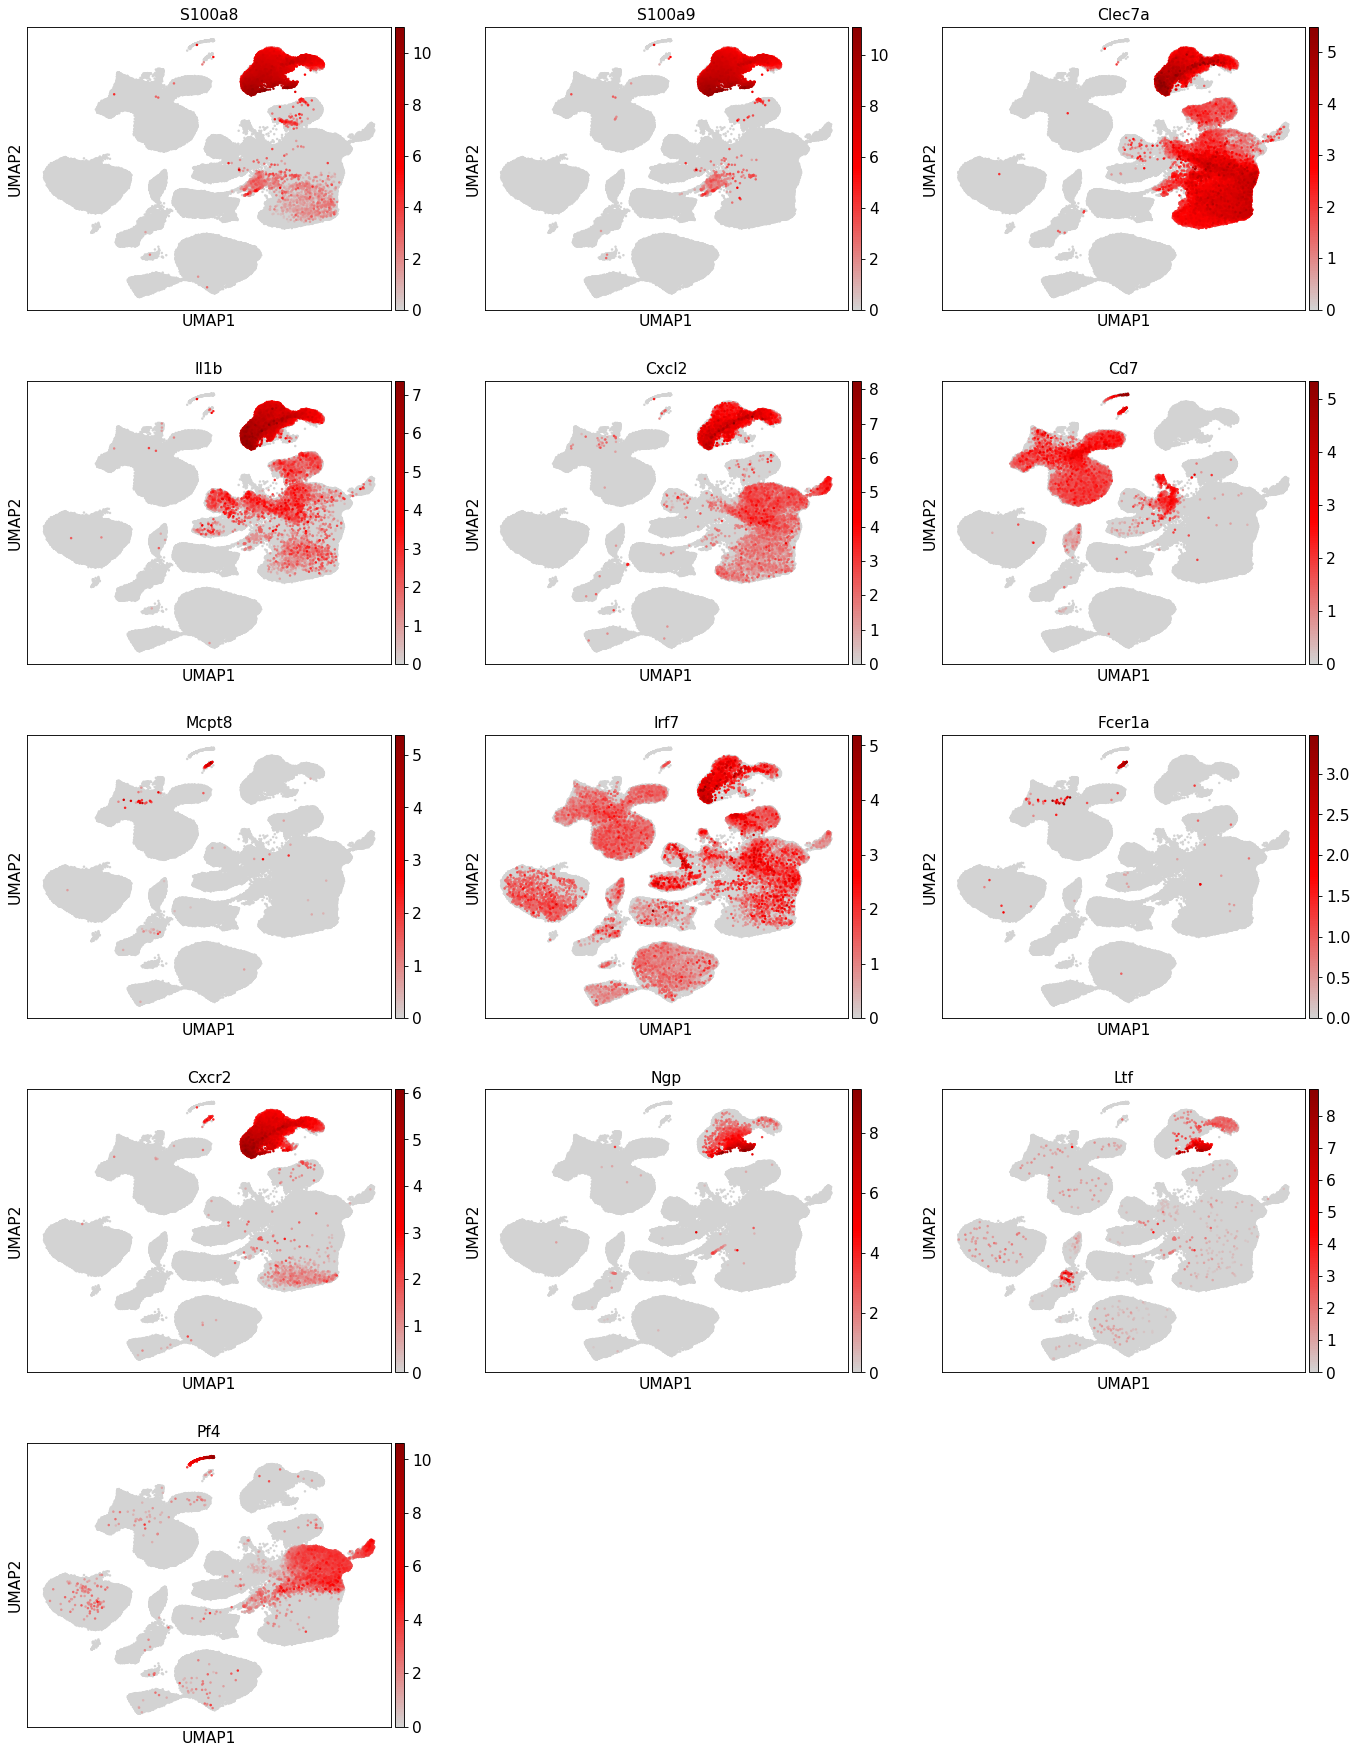

In [34]:
sc.pl.umap(adata, color = ['S100a8', 'S100a9', 'Clec7a', 'Il1b','Cxcl2', # Eosinophils
                           'Cd7',  'Mcpt8', 'Irf7', 'Fcer1a', 'Cxcr2', # Basophils
                           'Ngp', 'Ltf', 'Pf4', # Neutrophils
                           ], ncols=3, size=20, 
           color_map=gray_red)

### Save Granulocyte subset

In [35]:
granulocyte_subset = adata[adata.obs['louvain_1'].isin(['8', '24', '31', '34'])]

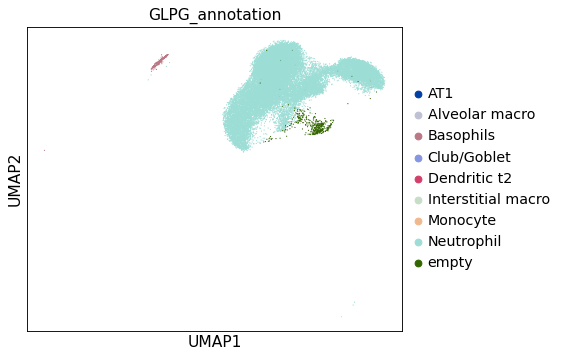

In [36]:
sc.pl.umap(granulocyte_subset, color=['GLPG_annotation'])

In [37]:
granulocyte_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_granulocyte_subset_NIKLAS.h5ad')

## Megakaryocyte subset

### Plot marker genes

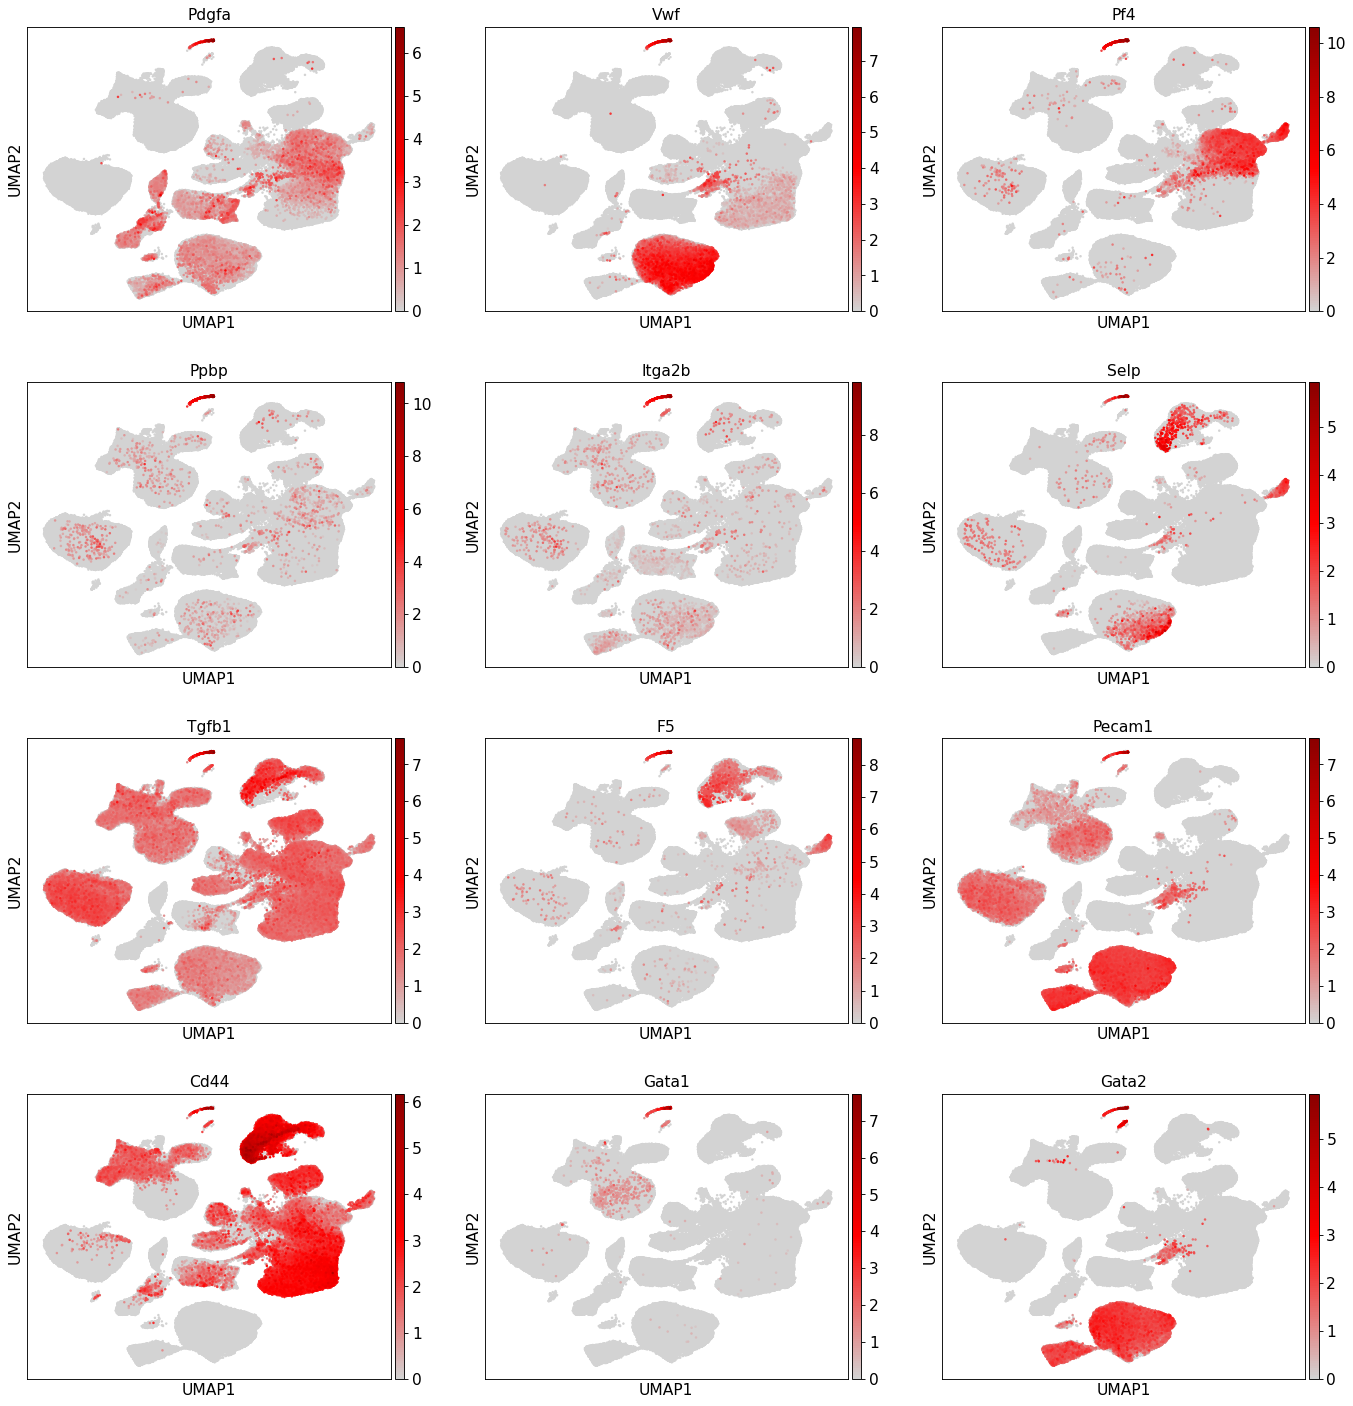

In [38]:
sc.pl.umap(adata, color = ['Pdgfa', 'Vwf', 'Pf4', 'Ppbp', 'Itga2b', 'Selp', 'Tgfb1', 'F5',
                           'Pecam1', 'Cd44', 'Gata1', 'Gata2'
                           ], ncols=3, size=20, 
           color_map=gray_red)

### Save Megakaryocyte subset

In [39]:
megakaryocyte_subset = adata[adata.obs['louvain_1'].isin(['32'])]

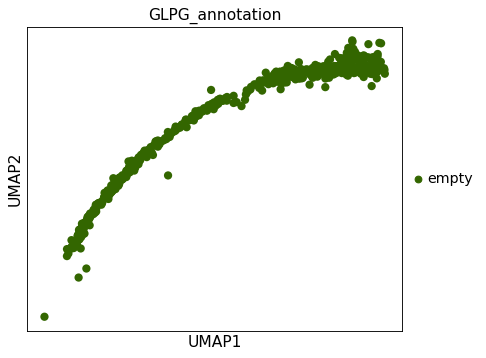

In [40]:
sc.pl.umap(megakaryocyte_subset, color=['GLPG_annotation'])

In [41]:
megakaryocyte_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_megakaryocyte_subset_NIKLAS.h5ad')

## Lymphocyte subset

### Plot marker genes

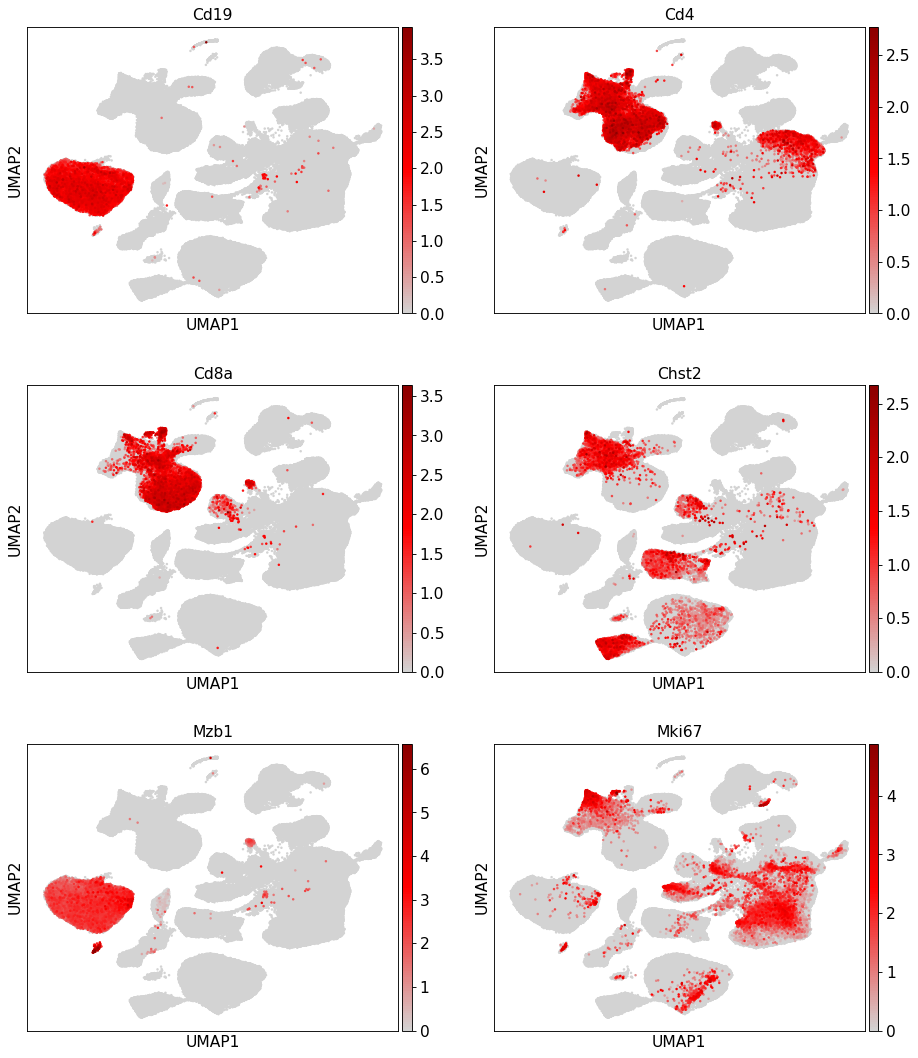

In [42]:
sc.pl.umap(adata, color = ['Cd19','Cd4','Cd8a', 'Chst2','Mzb1', 'Mki67'], ncols=2, size=20, color_map = gray_red)

### Save lymphocyte subset

In [43]:
lymphocyte_subset = adata[adata.obs['louvain_1'].isin(['0','6','20','33',
                                                      '2','5','9','15','28'])]

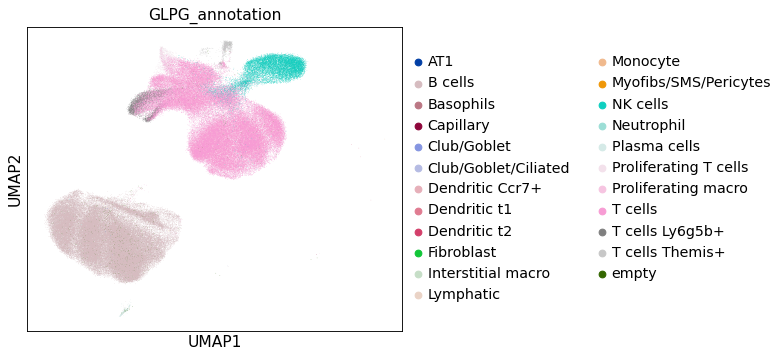

In [44]:
sc.pl.umap(lymphocyte_subset, color=['GLPG_annotation'])

In [45]:
lymphocyte_subset.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210211_lymphocyte_subset_NIKLAS.h5ad')